# ascent-agri — regime-aware robusta coffee backtest, end to end

A single-instrument case study: **regime detection (HMM) + a two-sleeve alpha stack
(trend / mean-reversion) + long-only position sizing + honest walk-forward
out-of-sample evaluation** on coffee futures, with **BRL/USD** and **Vietnam
Central Highlands weather** as regime inputs.

**Data, honestly stated:**
- The *real* deliverable series — roll-adjusted continuous ICE Robusta — currently
  spans one contract (RMU26, ~17 months). It runs at the end of this notebook,
  but supports only ~2 walk-forward folds.
- The main demonstration therefore uses the **ICE Arabica `KC=F` dev stand-in**
  (Yahoo, 2018–2026), the labeled substitute this repo established while robusta
  contracts are collected. Arabica ≠ robusta; the point here is the *system*, not
  the specific price series.
- BRL/USD: FRED `DEXBZUS` with Yahoo `BRL=X` fallback (Brazil is the dominant
  producer; a weakening BRL is a classic bearish coffee driver).
  Weather: Open-Meteo daily rainfall/temperature at Buon Ma Thuot, Dak Lak —
  the heart of the robusta belt.

**Long-only by design** — score-to-position mapping never shorts coffee. This is
an agricultural systems project, not a trading pitch.

In [1]:
import logging, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

logging.basicConfig(level=logging.ERROR)
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 110, "figure.figsize": (11, 4),
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.labelsize": 9,
    "legend.frameon": False, "font.size": 9,
})

# validated categorical palette (fixed slot order) + repo posture status colors
C_STRAT, C_BENCH, C_YELLOW, C_VIOLET = "#2a78d6", "#1baf7a", "#eda100", "#4a3aa7"
REGIME_COLORS = {          # status colors: same mapping as ascentagri/regime/posture.py
    "calm_bull": "#22c55e", "euphoric": "#84cc16", "stressed": "#f59e0b",
    "crisis": "#ef4444", "uncertain": "#64748b",
}

from ascentagri.config import get_config
from ascentagri.macro_fetch import ensure_caches, load_brlusd, load_weather
from ascentagri.regime.engine import RegimeEngine
from ascentagri.regime.features import RegimeFeatureBuilder
from ascentagri.alpha.stack import build_features, build_positions
from ascentagri.alpha.trend import trend_alpha
from ascentagri.alpha.meanrev import meanrev_alpha
from ascentagri.research.walk_forward_runner import run_walk_forward, print_wf_report

## 1 · Load the data

Price series + the two external regime inputs. `ensure_caches()` fetches BRL/USD and weather once into `data/processed/` (network on first run only).

In [2]:
close_df = pd.read_csv("data/processed/coffee_KCF_yahoo.csv",
                       parse_dates=["date"]).set_index("date").sort_index()
close, open_ = close_df["close"], close_df["open"]

robusta = pd.read_csv("data/processed/robusta_continuous.csv",
                      parse_dates=["date"]).set_index("date").sort_index()["close"]

ensure_caches()
brl = load_brlusd()
weather = load_weather()

print(f"stand-in (KC=F arabica): {len(close)} rows  {close.index[0].date()} -> {close.index[-1].date()}")
print(f"robusta  (real, 1 contract): {len(robusta)} rows  {robusta.index[0].date()} -> {robusta.index[-1].date()}")
print(f"BRL/USD: {len(brl)} rows   weather (Buon Ma Thuot): {len(weather)} rows")

stand-in (KC=F arabica): 2134 rows  2018-01-02 -> 2026-06-25
robusta  (real, 1 contract): 357 rows  2025-01-29 -> 2026-06-24
BRL/USD: 2471 rows   weather (Buon Ma Thuot): 3464 rows


## 2 · Regime detection

A Gaussian HMM (K=3) on trailing price features plus the BRL and weather groups, with an asymmetric-hysteresis decision layer (defensive transitions trigger faster than upgrades) and a rule-based crisis override (5-day crash + realized-vol confirmation).

*The overlay below is a **full-sample fit for visualization only** — the walk-forward section refits the regime engine inside each training fold, which is the only place performance claims come from.*

In [3]:
engine = RegimeEngine()
engine.fit(close, brl_usd=brl, weather=weather,
           run_model_selection=False, k_override=3, hmm_restarts=5)
signals = engine.get_signal_series()
occupancy = signals["label"].value_counts()
print("regime occupancy (full-sample visualization fit):")
print(occupancy.to_string())

regime occupancy (full-sample visualization fit):
label
calm_bull    932
crisis       616
stressed     586


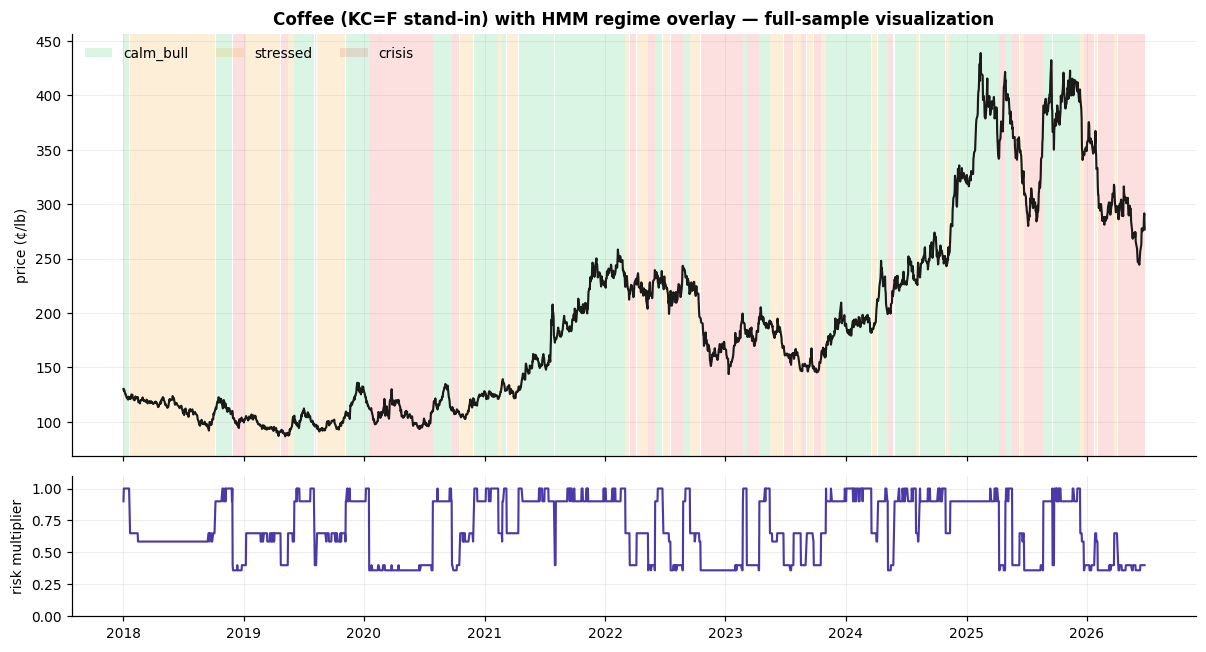

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1]})
ax = axes[0]
ax.plot(close.index, close.values, color="#1a1a19", lw=1.4)
lbl = signals["label"]
blocks = (lbl != lbl.shift()).cumsum()
seen = set()
for _, seg in lbl.groupby(blocks):
    name = seg.iloc[0]
    ax.axvspan(seg.index[0], seg.index[-1], color=REGIME_COLORS[name],
               alpha=0.16, lw=0, label=name if name not in seen else None)
    seen.add(name)
ax.set_title("Coffee (KC=F stand-in) with HMM regime overlay — full-sample visualization")
ax.set_ylabel("price (¢/lb)")
ax.legend(ncol=len(seen), loc="upper left")

ax2 = axes[1]
ax2.plot(signals.index, signals["risk_multiplier"], color=C_VIOLET, lw=1.4)
ax2.set_ylabel("risk multiplier")
ax2.set_ylim(0, 1.1)
ax2.xaxis.set_major_locator(mdates.YearLocator())
plt.tight_layout(); plt.show()

### 2b · The external regime inputs — BRL/USD and Central Highlands weather

The features the regime model actually consumes: FX momentum/vol of the producer currency, and causal rainfall/temperature anomalies at the growing region (each window z-scored against its own trailing year).

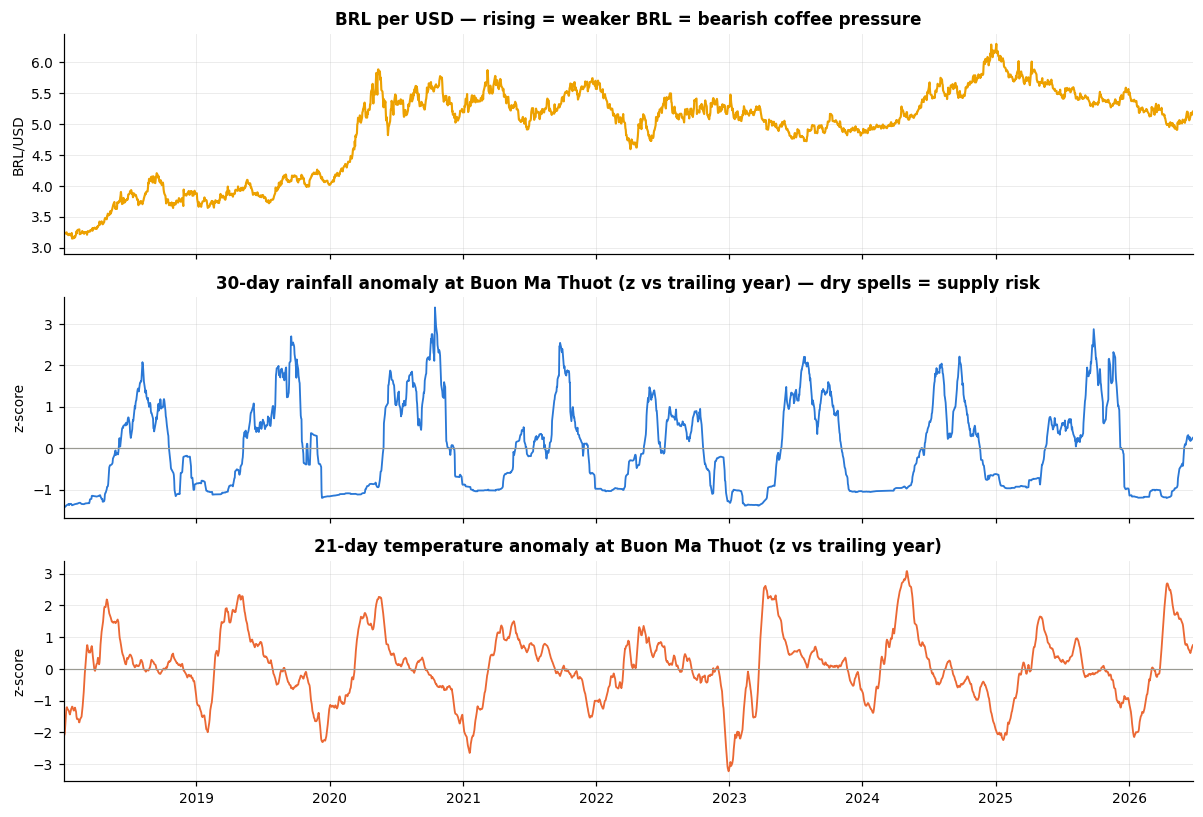

In [5]:
builder = RegimeFeatureBuilder(close, brl_usd=brl, weather=weather)
panel = builder.build()

fig, axes = plt.subplots(3, 1, figsize=(11, 7.5), sharex=True)
axes[0].plot(brl.index, brl.values, color=C_YELLOW, lw=1.4)
axes[0].set_title("BRL per USD — rising = weaker BRL = bearish coffee pressure")
axes[0].set_ylabel("BRL/USD")

axes[1].plot(panel.index, panel["rain_anom_30d"], color=C_STRAT, lw=1.2)
axes[1].axhline(0, color="#9a9a92", lw=0.8)
axes[1].set_title("30-day rainfall anomaly at Buon Ma Thuot (z vs trailing year) — dry spells = supply risk")
axes[1].set_ylabel("z-score")

axes[2].plot(panel.index, panel["temp_anom_21d"], color="#eb6834", lw=1.2)
axes[2].axhline(0, color="#9a9a92", lw=0.8)
axes[2].set_title("21-day temperature anomaly at Buon Ma Thuot (z vs trailing year)")
axes[2].set_ylabel("z-score")
axes[2].set_xlim(close.index[0], close.index[-1])
plt.tight_layout(); plt.show()

## 3 · Alpha stack → long-only position

Two sleeves — trend (75%) and short-term mean-reversion (25%) — each normalized with a **rolling time-series z-score** (the ported cross-sectional z-score silently returns zero for a single instrument; this was the key rewrite). Regime adjusts the sleeve mix per date, then the composite maps to exposure in [0, 1]: `clip(score, 0, 1.5) / 1.5`, scaled by the regime risk multiplier, a vol-target overlay (20% ann.) and a 200-day-MA filter (×0.70 below).

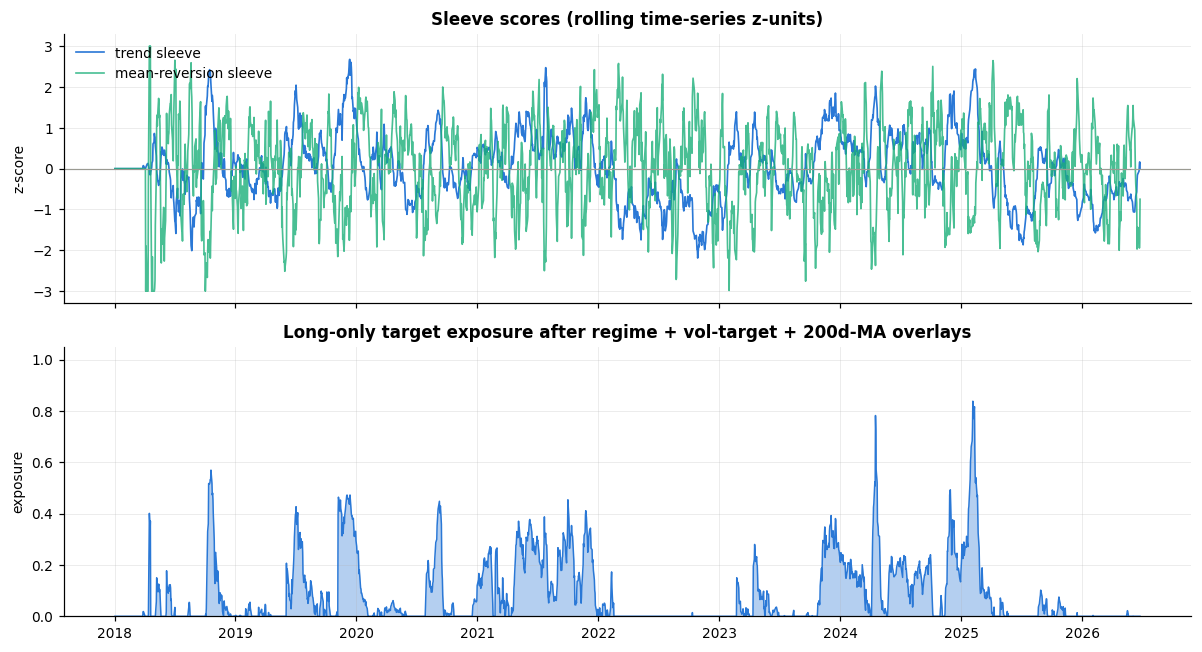

mean exposure 0.09 | days fully flat 51%


In [6]:
feats = build_features(close)
tr = trend_alpha(feats)
mr = meanrev_alpha(feats)
positions, diag = build_positions(close, regime_signal_df=signals)

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(tr.index, tr, color=C_STRAT, lw=1.1, label="trend sleeve")
axes[0].plot(mr.index, mr, color=C_BENCH, lw=1.1, alpha=0.8, label="mean-reversion sleeve")
axes[0].axhline(0, color="#9a9a92", lw=0.8)
axes[0].set_title("Sleeve scores (rolling time-series z-units)")
axes[0].legend(loc="upper left"); axes[0].set_ylabel("z-score")

axes[1].fill_between(positions.index, positions.values, color=C_STRAT, alpha=0.35, lw=0)
axes[1].plot(positions.index, positions.values, color=C_STRAT, lw=1.0)
axes[1].set_title("Long-only target exposure after regime + vol-target + 200d-MA overlays")
axes[1].set_ylabel("exposure"); axes[1].set_ylim(0, 1.05)
plt.tight_layout(); plt.show()
print(f"mean exposure {positions.mean():.2f} | days fully flat {(positions < 0.01).mean():.0%}")

## 4 · Walk-forward out-of-sample evaluation

The honest path — the only numbers this project quotes. Each fold: regime engine **refit on the training slice only** (fixed K=3, no per-fold parameter tuning), signals scored causally into the test window, positions rebuilt, backtest with 1-day execution delay and 10 bps costs, 5-day purge between train and test. Failed folds are reported, never silently zeroed.

In [7]:
cfg = get_config()
result = run_walk_forward(close, open_prices=open_, brl_usd=brl,
                          weather=weather, config=cfg, verbose=False)
print_wf_report(result)
folds = pd.DataFrame(result.fold_summaries).set_index("fold_id")
folds

  WALK-FORWARD OOS PERFORMANCE REPORT
  OOS Window        : 2020-01-10 → 2026-06-25
  OOS Trading Days  : 1625
  Folds             : 26  (0 failed)
  CAGR              : +0.93%
  Volatility        : 6.12%
  Sharpe Ratio      : 0.183
  Sortino Ratio     : 0.125
  Max Drawdown      : -9.19%
  Win Rate          : 25.4%
-------------------------------------------------------
  Buy&Hold CAGR     : +14.23%
  Alpha vs B&H      : -13.30%
  Beta vs B&H       : 0.085
-------------------------------------------------------
  Walk-Forward Eff. : -2.505  (OVERFIT — do not trade)


,train,test,status,is_sharpe,oos_sharpe,oos_days,dominant_regime,mean_exposure
fold_id,,,,,,,,
0,2018-01-02→2020-01-02,2020-01-10→2020-04-09,ok,0.194,-3.020,63,crisis,0.034
1,2018-04-04→2020-04-02,2020-04-13→2020-07-10,ok,0.086,-2.864,63,crisis,0.016
2,2018-07-03→2020-07-02,2020-07-13→2020-10-08,ok,-0.142,-1.780,63,calm_bull,0.134
3,2018-10-02→2020-10-01,2020-10-09→2021-01-08,ok,-0.281,-0.544,63,calm_bull,0.023
4,2019-01-03→2020-12-31,2021-01-11→2021-04-12,ok,-0.329,-0.488,63,calm_bull,0.118
5,2019-04-04→2021-04-05,2021-04-13→2021-07-12,ok,-0.355,0.499,63,calm_bull,0.244
6,2019-07-05→2021-07-02,2021-07-13→2021-10-08,ok,-0.060,0.639,63,calm_bull,0.146
7,2019-10-03→2021-10-01,2021-10-11→2022-01-07,ok,0.384,0.565,63,calm_bull,0.180
8,2020-01-03→2021-12-31,2022-01-10→2022-04-08,ok,0.244,-0.275,63,calm_bull,0.018


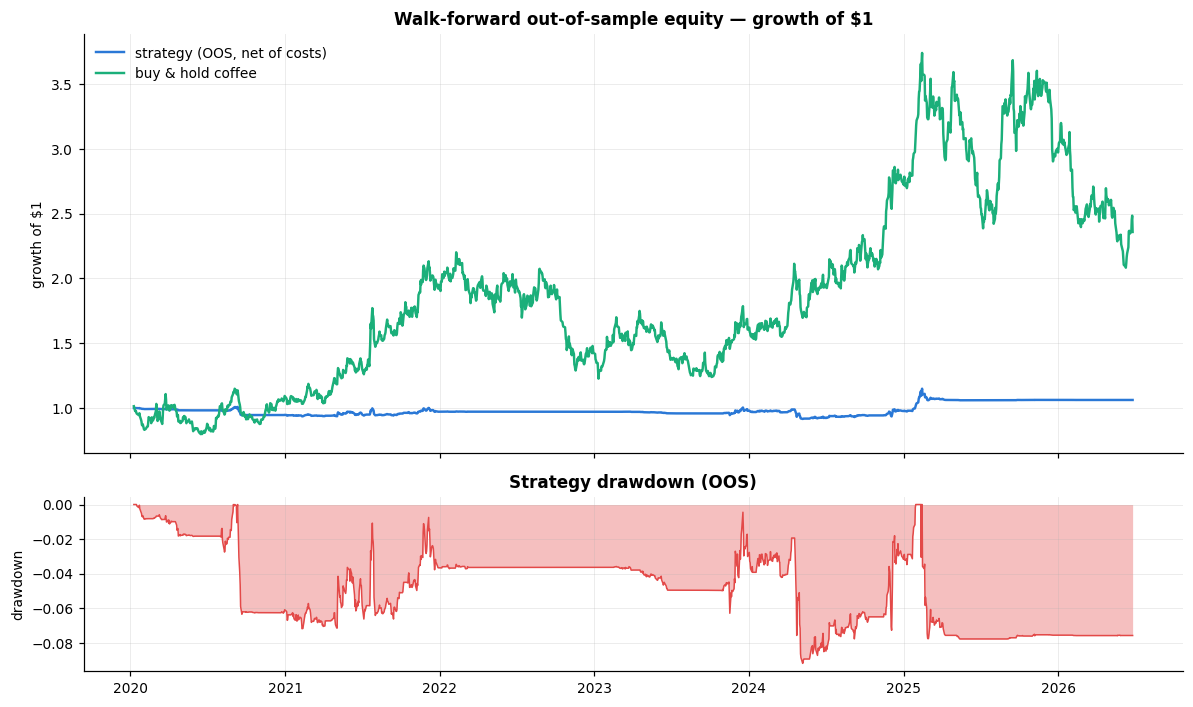

In [8]:
oos_eq = result.equity_curve
bh_eq = (1 + result.benchmark_returns).cumprod()
dd = oos_eq / oos_eq.cummax() - 1

fig, axes = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True,
                         gridspec_kw={"height_ratios": [2.4, 1]})
axes[0].plot(oos_eq.index, oos_eq, color=C_STRAT, lw=1.6, label="strategy (OOS, net of costs)")
axes[0].plot(bh_eq.index, bh_eq, color=C_BENCH, lw=1.6, label="buy & hold coffee")
axes[0].set_title("Walk-forward out-of-sample equity — growth of $1")
axes[0].set_ylabel("growth of $1"); axes[0].legend(loc="upper left")

axes[1].fill_between(dd.index, dd.values, color="#e34948", alpha=0.35, lw=0)
axes[1].plot(dd.index, dd.values, color="#e34948", lw=1.0)
axes[1].set_title("Strategy drawdown (OOS)")
axes[1].set_ylabel("drawdown")
plt.tight_layout(); plt.show()

## 5 · The real robusta series

Same pipeline on the actual deliverable — the roll-adjusted continuous robusta series. With one contract downloaded (~17 months) only ~2 folds fit; **this is a data bottleneck, not a code limitation** — the pipeline is identical, and more Databento/Barchart contracts extend it with no code change.

In [9]:
cfg_r = get_config(wf_train_days=252, wf_test_days=63, wf_step_days=63,
                   wf_min_train_days=200)
result_r = run_walk_forward(robusta, brl_usd=brl, weather=weather,
                            config=cfg_r, verbose=True)
print_wf_report(result_r)

[WF] 2 folds | train=252d test=63d step=63d purge=5d | 2025-01-29 → 2026-06-24


[WF] fold  0 ok   IS Sharpe -1.51 | OOS Sharpe +3.29 | regime crisis | mean exp 0.01


[WF] fold  1 ok   IS Sharpe -1.53 | OOS Sharpe +6.67 | regime crisis | mean exp 0.01
[WF] complete: 2 folds succeeded, 0 failed, 100 OOS days in 0.3s
  WALK-FORWARD OOS PERFORMANCE REPORT
  OOS Window        : 2026-01-30 → 2026-06-24
  OOS Trading Days  : 100
  Folds             : 2  (0 failed)
  CAGR              : +1.72%
  Volatility        : 0.36%
  Sharpe Ratio      : 4.693
  Sortino Ratio     : 5.491
  Max Drawdown      : -0.09%
  Win Rate          : 29.0%
-------------------------------------------------------
  Buy&Hold CAGR     : -18.51%
  Alpha vs B&H      : +20.23%
  Beta vs B&H       : 0.006
-------------------------------------------------------
  Walk-Forward Eff. : n/a (no folds with positive IS Sharpe)


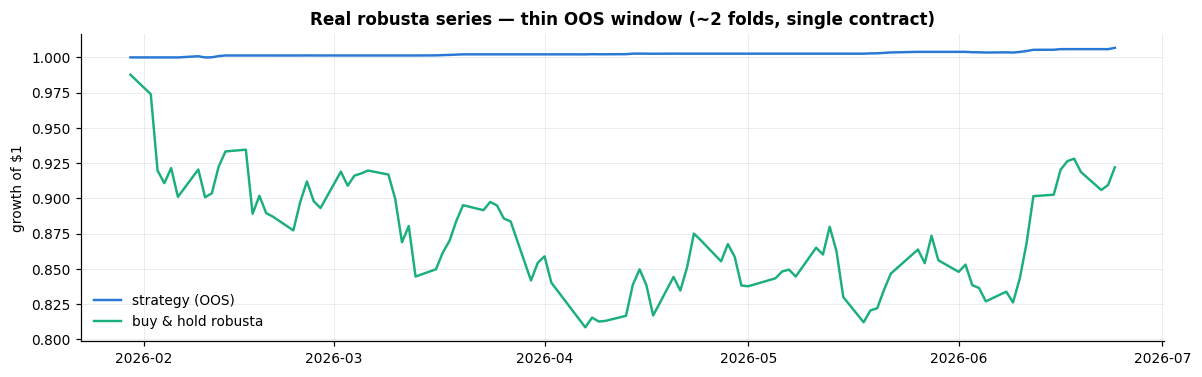

In [10]:
fig, ax = plt.subplots(figsize=(11, 3.5))
eq_r = result_r.equity_curve
bh_r = (1 + result_r.benchmark_returns).cumprod()
ax.plot(eq_r.index, eq_r, color=C_STRAT, lw=1.6, label="strategy (OOS)")
ax.plot(bh_r.index, bh_r, color=C_BENCH, lw=1.6, label="buy & hold robusta")
ax.set_title("Real robusta series — thin OOS window (~2 folds, single contract)")
ax.set_ylabel("growth of $1"); ax.legend(loc="lower left")
plt.tight_layout(); plt.show()

## 6 · What the numbers actually say

Read the report above plainly:

- **The strategy under-performs buy-and-hold on the stand-in window and WFE is
  negative.** Coffee 2024–25 was a violent, volatility-fueled bull market; the
  HMM associates high volatility with its worst state, the hysteresis layer holds
  that label, and the risk multiplier + vol-target overlay cut exposure exactly
  when the market ran. A long-only defensive system under-participates in a
  vol-up rally — the framework is doing what it was told, and the walk-forward
  reports it honestly rather than hiding it.
- **Negative WFE means in-sample fit does not transfer here.** That is a finding,
  not a failure of the harness: the evaluation machinery (fold-local refits,
  purge gaps, delayed execution, visible failed folds) is the deliverable.
- **The robusta result is not evidence either way** — two folds on 17 months of a
  single contract. The path to a real answer is more contract history, and the
  data layer (Databento fetch → roll adjustment) is already built for it.

The systems point this artifact demonstrates: every performance number above is
produced by machinery designed to make lying to yourself hard — point-in-time
regime fits, causal features, execution delay, transaction costs, purged splits,
and failure visibility.